In [1]:
# Import libraries for modelling 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pickle

# Set up professional  visualization style 

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the scaled data
df_scaled = pd.read_csv('../data/mall_customers_scaled.csv')

# Also load the original processed data for interpretation
df_original = pd.read_csv('../data/mall_customers_processed.csv')

print("Data loaded successfully!")
print(f"Scaled data shape: {df_scaled.shape}")
print(f"Original data shape: {df_original.shape}")
print("\nFirst 5 rows of scaled data:")
df_scaled.head()

Data loaded successfully!
Scaled data shape: (200, 4)
Original data shape: (200, 4)

First 5 rows of scaled data:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,-1.424569,-1.738999,-0.434801
1,1,-1.281035,-1.738999,1.195704
2,0,-1.352802,-1.700830,-1.715913
3,0,-1.137502,-1.700830,1.040418
4,0,-0.563369,-1.662660,-0.395980


In [3]:
# For customer segmentation, we'll use Annual Income and Spending Score
# These two features best define customer value

X = df_scaled[['Annual Income (k$)', 'Spending Score (1-100)']]

print("Features selected for clustering:")
print(f"Features: {list(X.columns)}")
print(f"Shape: {X.shape}")
X.head()

Features selected for clustering:
Features: ['Annual Income (k$)', 'Spending Score (1-100)']
Shape: (200, 2)


,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


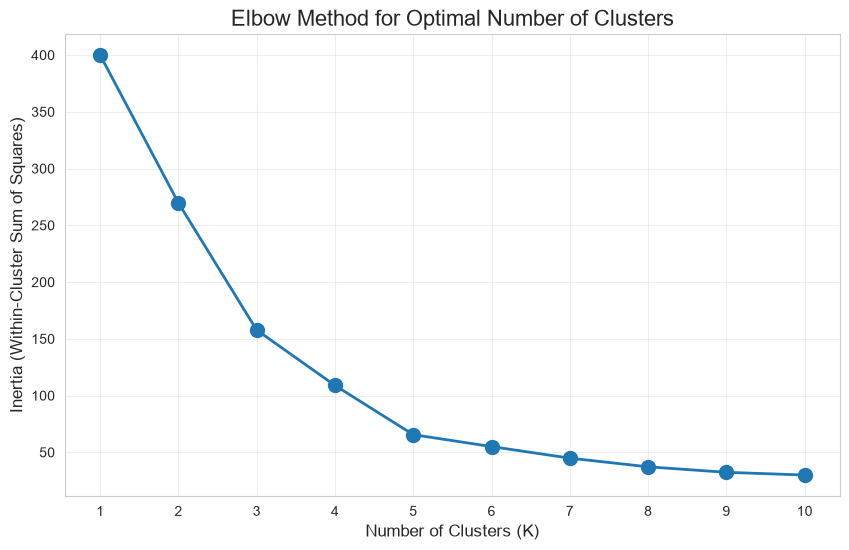

In [5]:
# Calculate inertia for different values of K using  the elbow method to find the optimal number of clusters
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Create the elbow plot
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linewidth=2, markersize=10)
plt.title('Elbow Method for Optimal Number of Clusters', fontsize=16)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(K_range)
plt.savefig('../images/elbow_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
#Train K-Means with k = 5 (as determined from the elbow plot)
# Set the optimal number of clusters
k = 5

# Initialize and train the model
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)

# Get the cluster labels
df_original['Cluster'] = kmeans.labels_
df_scaled['Cluster'] = kmeans.labels_

print("K-Means model trained successfully!")
print(f"Number of clusters: {k}")
print(f"Cluster labels: {kmeans.labels_[:10]} (first 10 customers)")

# Get the cluster centers (in scaled space)
print("\nCluster centers (scaled coordinates):")
print(kmeans.cluster_centers_)

K-Means model trained successfully!
Number of clusters: 5
Cluster labels: [4 2 4 2 4 2 4 2 4 2] (first 10 customers)

Cluster centers (scaled coordinates):
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [7]:
# Get the cluster centers (in scaled space)
cluster_centers_scaled = kmeans.cluster_centers_

print("Cluster centers (scaled coordinates):")
print("Each row represents a cluster, columns are [Income, Spending]")
print(cluster_centers_scaled)
print("\nInterpretation:")
print(f"Cluster 0 center: Income={cluster_centers_scaled[0][0]:.2f}, Spending={cluster_centers_scaled[0][1]:.2f}")
print(f"Cluster 1 center: Income={cluster_centers_scaled[1][0]:.2f}, Spending={cluster_centers_scaled[1][1]:.2f}")
print(f"Cluster 2 center: Income={cluster_centers_scaled[2][0]:.2f}, Spending={cluster_centers_scaled[2][1]:.2f}")
print(f"Cluster 3 center: Income={cluster_centers_scaled[3][0]:.2f}, Spending={cluster_centers_scaled[3][1]:.2f}")
print(f"Cluster 4 center: Income={cluster_centers_scaled[4][0]:.2f}, Spending={cluster_centers_scaled[4][1]:.2f}")

Cluster centers (scaled coordinates):
Each row represents a cluster, columns are [Income, Spending]
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]

Interpretation:
Cluster 0 center: Income=-0.20, Spending=-0.03
Cluster 1 center: Income=0.99, Spending=1.24
Cluster 2 center: Income=-1.33, Spending=1.13
Cluster 3 center: Income=1.06, Spending=-1.28
Cluster 4 center: Income=-1.31, Spending=-1.14


In [8]:
#Convert the cluster centers back to the original scale for interpretation
# Load the scaler to reverse transform

with open('../src/scaler.pkl', 'rb') as file:
    scaler = pickle.load(file)

# Get cluster centers in original scale
# Since we only used Income and Spending, we need to create a full feature array
# The scaler was trained on: Age, Income, Spending
feature_names = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Create a full matrix with the same features as the scaler was trained on
# We only have Income and Spending from K-Means, so we'll add Age as 0 (mean)
cluster_centers_full = np.zeros((k, 3))  # 3 features: Age, Income, Spending
cluster_centers_full[:, 1] = cluster_centers_scaled[:, 0]  # Income (scaled)
cluster_centers_full[:, 2] = cluster_centers_scaled[:, 1]  # Spending (scaled)
# Age stays 0 (mean)

# Inverse transform to original scale
cluster_centers_original = scaler.inverse_transform(cluster_centers_full)

# Create a DataFrame for easy viewing
cluster_centers_df = pd.DataFrame(cluster_centers_original, 
                                   columns=feature_names)
cluster_centers_df['Cluster'] = range(k)

print("Cluster centers in original scale:")
print(cluster_centers_df)

Cluster centers in original scale:
     Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0  38.85           55.296296               49.518519        0
1  38.85           86.538462               82.128205        1
2  38.85           25.727273               79.363636        2
3  38.85           88.200000               17.114286        3
4  38.85           26.304348               20.913043        4


In [9]:
# Count customers in each cluster
cluster_counts = df_original['Cluster'].value_counts().sort_index()

print("="*50)
print("CLUSTER DISTRIBUTION")
print("="*50)
for cluster_id in range(k):
    count = cluster_counts[cluster_id]
    percentage = (count / len(df_original)) * 100
    print(f"Cluster {cluster_id}: {count} customers ({percentage:.1f}%)")
print("="*50)

CLUSTER DISTRIBUTION
Cluster 0: 81 customers (40.5%)
Cluster 1: 39 customers (19.5%)
Cluster 2: 22 customers (11.0%)
Cluster 3: 35 customers (17.5%)
Cluster 4: 23 customers (11.5%)


In [10]:
# Create a detailed profile for each cluster
cluster_profile = df_original.groupby('Cluster').agg({
    'Age': ['mean', 'min', 'max'],
    'Annual Income (k$)': ['mean', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'min', 'max'],
    'Gender': lambda x: 'Female' if x.mean() < 0.5 else 'Male'
}).round(2)

# Add cluster size
cluster_profile['Size'] = df_original.groupby('Cluster').size()

print("="*60)
print("CUSTOMER SEGMENT PROFILES")
print("="*60)
print(cluster_profile)

CUSTOMER SEGMENT PROFILES
           Age         Annual Income (k$)          Spending Score (1-100)      \
          mean min max               mean min  max                   mean min   
Cluster                                                                         
0        42.72  18  70              55.30  39   76                  49.52  34   
1        32.69  27  40              86.54  69  137                  82.13  63   
2        25.27  18  35              25.73  15   39                  79.36  61   
3        41.11  19  59              88.20  70  137                  17.11   1   
4        45.22  19  67              26.30  15   39                  20.91   3   

              Gender Size  
        max <lambda>       
Cluster                    
0        61   Female   81  
1        97   Female   39  
2        99   Female   22  
3        39     Male   35  
4        40   Female   23  


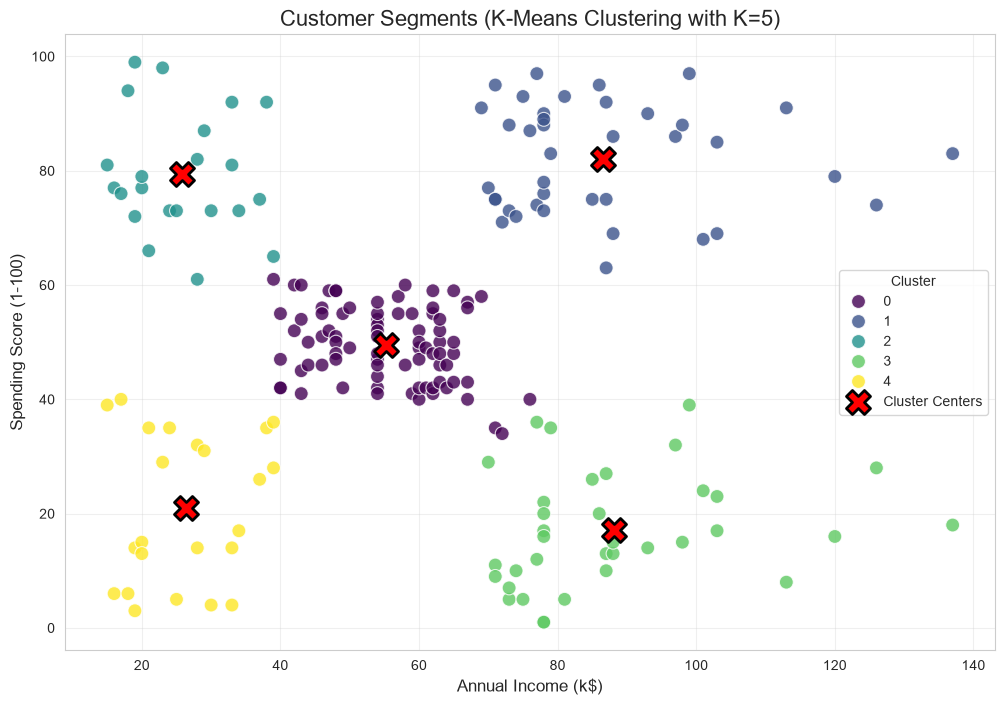

In [12]:
# Create the cluster visualization
plt.figure(figsize=(12, 8))

# Scatter plot with clusters colored
scatter = sns.scatterplot(
    data=df_original,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.8
)

# Plot cluster centers
centers = cluster_centers_df[['Annual Income (k$)', 'Spending Score (1-100)']].values
plt.scatter(centers[:, 0], centers[:, 1], 
           s=300, c='red', marker='X', edgecolors='black', linewidth=2,
           label='Cluster Centers')

plt.title('Customer Segments (K-Means Clustering with K=5)', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Cluster', loc='best')
plt.grid(alpha=0.3)
plt.savefig('../images/cluster_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# Create a detailed profile for each cluster
cluster_profile = df_original.groupby('Cluster').agg({
    'Age': ['mean', 'min', 'max'],
    'Annual Income (k$)': ['mean', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'min', 'max'],
    'Gender': lambda x: 'Female' if x.mean() < 0.5 else 'Male'
}).round(2)

# Add cluster size
cluster_profile['Size'] = df_original.groupby('Cluster').size()

# Add percentage
cluster_profile['Percentage'] = (cluster_profile['Size'] / len(df_original) * 100).round(1)

print("="*70)
print("CUSTOMER SEGMENT PROFILES")
print("="*70)
print(cluster_profile)

CUSTOMER SEGMENT PROFILES
           Age         Annual Income (k$)          Spending Score (1-100)      \
          mean min max               mean min  max                   mean min   
Cluster                                                                         
0        42.72  18  70              55.30  39   76                  49.52  34   
1        32.69  27  40              86.54  69  137                  82.13  63   
2        25.27  18  35              25.73  15   39                  79.36  61   
3        41.11  19  59              88.20  70  137                  17.11   1   
4        45.22  19  67              26.30  15   39                  20.91   3   

              Gender Size Percentage  
        max <lambda>                  
Cluster                               
0        61   Female   81       40.5  
1        97   Female   39       19.5  
2        99   Female   22       11.0  
3        39     Male   35       17.5  
4        40   Female   23       11.5  


In [16]:
print("="*70)
print("CUSTOMER SEGMENT INTERPRETATION")
print("="*70)
print()

# Store cluster information for later use
cluster_info = []

for cluster_id in range(5):
    # Get cluster data
    cluster_data = cluster_profile.loc[cluster_id]
    
    # Extract values - handle Series objects properly
    income = float(cluster_data[('Annual Income (k$)', 'mean')])
    spending = float(cluster_data[('Spending Score (1-100)', 'mean')])
    age = float(cluster_data[('Age', 'mean')])
    gender = cluster_data['Gender']
    
    # Extract size and percentage - use .values[0] to get the actual number
    size = int(cluster_data['Size'].values[0]) if hasattr(cluster_data['Size'], 'values') else int(cluster_data['Size'])
    percentage = float(cluster_data['Percentage'].values[0]) if hasattr(cluster_data['Percentage'], 'values') else float(cluster_data['Percentage'])
    
    # Determine segment name based on income and spending
    if income > 70 and spending > 60:
        name = "💰 High-Value Loyal Customers"
        description = "High income, high spending. Most valuable segment."
        action = "Reward with premium loyalty programs, exclusive offers"
        priority = "HIGHEST PRIORITY"
    elif income > 70 and spending < 40:
        name = "🛡️ Savers / Careful Spenders"
        description = "High income, low spending. Potential to increase spending."
        action = "Showcase value-for-money products, upsell premium items"
        priority = "HIGH PRIORITY"
    elif income < 40 and spending > 60:
        name = "💳 Spending Beyond Means"
        description = "Low income, high spending. Price sensitive but spend heavily."
        action = "Target with installment payment options, discounts on bulk purchases"
        priority = "MEDIUM PRIORITY"
    elif income < 40 and spending < 40:
        name = "📉 Low-Value Customers"
        description = "Low income, low spending. Need engagement."
        action = "Encourage purchases with introductory offers, coupons"
        priority = "MEDIUM PRIORITY"
    else:
        name = "⚖️ Average Customers"
        description = "Medium income, medium spending. Balanced segment."
        action = "Maintain satisfaction, occasional upselling"
        priority = "STANDARD"
    
    # Store for later
    cluster_info.append({
        'id': cluster_id,
        'name': name,
        'description': description,
        'action': action,
        'priority': priority,
        'income': income,
        'spending': spending,
        'age': age,
        'gender': gender,
        'size': size,
        'percentage': percentage
    })
    
    # Print using the extracted values
    print(f"CLUSTER {cluster_id}: {name}")
    print(f"  📊 Size: {size} customers ({percentage:.1f}%)")
    print(f"  👤 Average Age: {age:.1f} years")
    print(f"  💰 Average Income: ${income:.0f}k")
    print(f"  🛒 Average Spending Score: {spending:.0f}/100")
    print(f"  👫 Gender: {gender}")
    print(f"  📝 Description: {description}")
    print(f"  🎯 Priority: {priority}")
    print(f"  ✅ Recommended Action: {action}")
    print("-"*70)

CUSTOMER SEGMENT INTERPRETATION

CLUSTER 0: ⚖️ Average Customers
  📊 Size: 81 customers (40.5%)
  👤 Average Age: 42.7 years
  💰 Average Income: $55k
  🛒 Average Spending Score: 50/100
  👫 Gender: <lambda>    Female
Name: 0, dtype: str
  📝 Description: Medium income, medium spending. Balanced segment.
  🎯 Priority: STANDARD
  ✅ Recommended Action: Maintain satisfaction, occasional upselling
----------------------------------------------------------------------
CLUSTER 1: 💰 High-Value Loyal Customers
  📊 Size: 39 customers (19.5%)
  👤 Average Age: 32.7 years
  💰 Average Income: $87k
  🛒 Average Spending Score: 82/100
  👫 Gender: <lambda>    Female
Name: 1, dtype: str
  📝 Description: High income, high spending. Most valuable segment.
  🎯 Priority: HIGHEST PRIORITY
  ✅ Recommended Action: Reward with premium loyalty programs, exclusive offers
----------------------------------------------------------------------
CLUSTER 2: 💳 Spending Beyond Means
  📊 Size: 22 customers (11.0%)
  👤 Average

In [17]:
# Create a clean summary table for your report
summary_table = pd.DataFrame({
    'Cluster': [f"Cluster {i}" for i in range(5)],
    'Segment Name': [info['name'] for info in cluster_info],
    'Size': [info['size'] for info in cluster_info],
    'Percentage': [f"{info['percentage']:.1f}%" for info in cluster_info],
    'Avg Income': [f"${info['income']:.0f}k" for info in cluster_info],
    'Avg Spending': [f"{info['spending']:.0f}/100" for info in cluster_info],
    'Avg Age': [f"{info['age']:.1f} yrs" for info in cluster_info],
    'Gender': [info['gender'] for info in cluster_info],
    'Priority': [info['priority'] for info in cluster_info]
})

print("="*70)
print("CUSTOMER SEGMENT SUMMARY TABLE")
print("="*70)
print(summary_table.to_string(index=False))

CUSTOMER SEGMENT SUMMARY TABLE
  Cluster                 Segment Name  Size Percentage Avg Income Avg Spending  Avg Age                                 Gender         Priority
Cluster 0         ⚖️ Average Customers    81      40.5%       $55k       50/100 42.7 yrs <lambda>    Female
Name: 0, dtype: str         STANDARD
Cluster 1 💰 High-Value Loyal Customers    39      19.5%       $87k       82/100 32.7 yrs <lambda>    Female
Name: 1, dtype: str HIGHEST PRIORITY
Cluster 2      💳 Spending Beyond Means    22      11.0%       $26k       79/100 25.3 yrs <lambda>    Female
Name: 2, dtype: str  MEDIUM PRIORITY
Cluster 3 🛡️ Savers / Careful Spenders    35      17.5%       $88k       17/100 41.1 yrs   <lambda>    Male
Name: 3, dtype: str    HIGH PRIORITY
Cluster 4        📉 Low-Value Customers    23      11.5%       $26k       21/100 45.2 yrs <lambda>    Female
Name: 4, dtype: str  MEDIUM PRIORITY


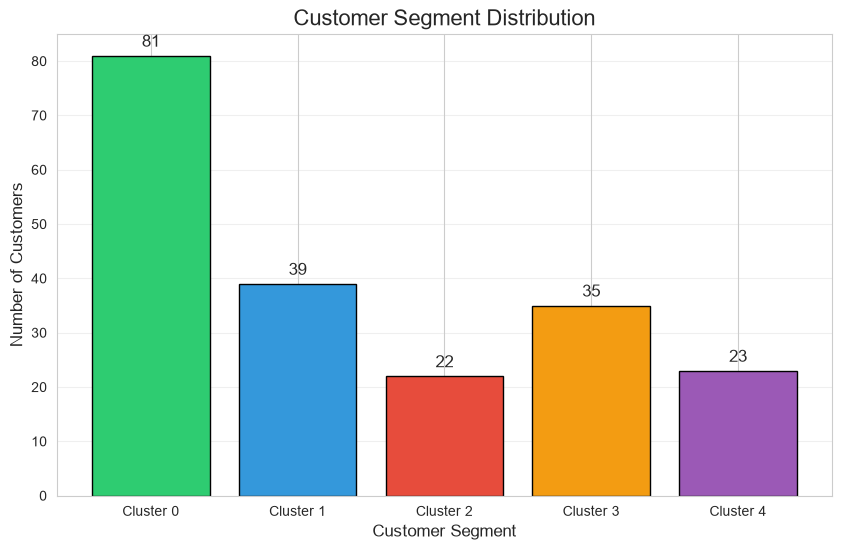

In [18]:
# Create a bar chart showing cluster sizes
plt.figure(figsize=(10, 6))
cluster_sizes = [info['size'] for info in cluster_info]
cluster_names = [f"Cluster {i}" for i in range(5)]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

bars = plt.bar(cluster_names, cluster_sizes, color=colors, edgecolor='black')
plt.title('Customer Segment Distribution', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add value labels on bars
for bar, size in zip(bars, cluster_sizes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             str(size), ha='center', va='bottom', fontsize=12)

plt.grid(alpha=0.3, axis='y')
plt.savefig('../images/business_insights.png', dpi=300, bbox_inches='tight')
plt.show()